## Statistics with Python: Correlation and Linear Regression

1. Pearson correlation coefficient
2. P-value
3. Linear regression
4. Coefficient of determination
5. Non-linear transformation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

As an example dataset, I'll take height and weight dataset. It seems true that these two properties influence each other in some way, but here we can try to check it ourselves.

In [ ]:
data = pd.read_csv('SOCR-HeightWeight.csv')

In [4]:
data.head()

,Index,Height(Inches),Weight(Pounds)
0,1,65.78331,112.9925
1,2,71.51521,136.4873
2,3,69.39874,153.0269
3,4,68.21660,142.3354
4,5,67.78781,144.2971


In [ ]:
# Converting to metric system:
data['height'] = data['Height(Inches)']*2.54 #(1 inch = 2.54 cm)
data['weight'] = data['Weight(Pounds)']*0.4535924 #(1 pound = 0.4535924 kg)

Quick look at the data:

<Axes: xlabel='height', ylabel='weight'>

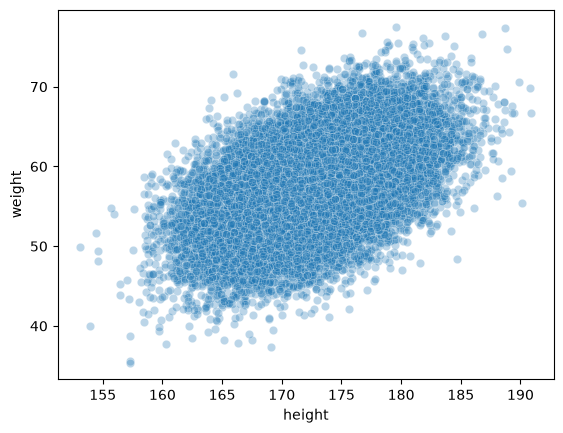

In [7]:
sns.scatterplot(data = data, x = 'height', y = 'weight', alpha = 0.3)

#### 1. Pearson correlation coefficient

Correlation coefficient measures strength and direction of linear correlation between two variables. Values of the correlation can be between -1 and 1, where =1 - when one variable grows, the other one laso grows, =-1 - when one grows the other one decreases, and 0 means that there is no correlation. In order to calculate it, first we need to find the value of covariance, which is variability of the two variables: $$Cov(X, Y) = \frac{\sum_{i=1}^{n}(x_i - \bar{x})(y_i - \bar{y})}{N}$$
where $x_i$, $y_i$ are elements of the dataset, $\bar{x}$, $\bar{y}$ are mean values of the variables and N is the population size (alternatively $n-1$ for the sample). Pearson's correlation coefficient is calculated using the following formula: $$\rho_{X,Y} = \frac{Cov(X, Y)}{\sigma_{X}\sigma_{Y}}$$
where $\sigma_{X}, \sigma_{Y}$ are standard deviations of X and Y. In python we could create a function that would calculate this:

In [8]:
def pearson(x, y):
    pearson = ((((x - x.mean())*(y - y.mean())).sum())/x.count())/(np.std(x)*np.std(y))
    return pearson

Now we can use this function to check the correlation between height and weight from previously loaded dataset:

In [9]:
pearson(data['height'], data['weight'])

0.5028585206028435

We could also use pandas correlation function:

In [10]:
datacorr = data[['height', 'weight']].corr()
datacorr

,height,weight
height,1.000000,0.502859
weight,0.502859,1.000000


Standard way of visualizing correlation is a heatmap, where we can immediately see which pairs of variables have stronger or weaker correlation.

<Axes: >

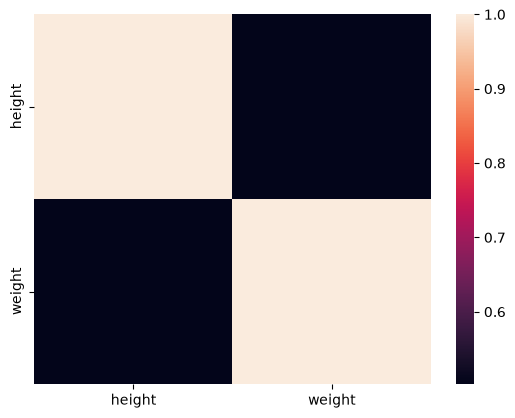

In [11]:
sns.heatmap(data = datacorr)

Based on these outcomes, we can tell that there is moderate correlation of 0.5 between height and weight.

It is also important to remember that correlation is not causation. A classic example illustrating the absurdity of assuming causation in the case of correlation is "ice cream sales and shark attacks." During the summer, ice cream sales increase, and with them the number of shark attacks, as more people swim in the ocean at this time of year. But it would be absurd to claim that one causes the other, moreover there is no way of deciding which would cause which. Let's also look at our example above, which might be more misleading, where we try to find the correlation between height and weight. Based on correlation formula itself, it is meaningless to say whether certain height causes certain weight or vice versa. Even if we have our own reasoning that taller people are bigger and therefore weigh more, this is our own assumption that is not subject to correlation. Only thing that we can say here is that those values tend to increase or decrease together.

#### 2. P-value

P-value is a statistical measure which helps in deciding whether the outcome of the experiment is due to chance or not. First thing to do here is to establish the null hypothesis, which is the assumption that the effect, correlation, relationship etc. does not exist. For the case of our correlation we could establish null hypothesis as: $H_0$ = There is no correlation between height and weight. Now we can ask, assuming that $H_0$ is true, how surprising would the result be, in this case a moderate correlation of 0.5. So, the p-value is:

p-value = P(observing_r_this_extreme|$H_0$ is true)

where when p-value < 0.05, then the $H_0$ is rejected, and when p-value >= 0.05, then we failed to reject the $H_0$.

In order to get the p-value of the correlation, we can use the following function from scipy.stats library:

In [12]:
from scipy.stats import pearsonr

r, p_value = pearsonr(data['height'], data['weight'])
print(r, p_value)

0.5028585206028426 0.0


The p-value turned out to be 0.0, which means we can reject the null hypothesis. This means that our correlation outcome is most likely not due to random chance.

#### 3. Linear Regression

Linear regression is a statistical method for modeling the relationship between output variable and input variable. We can think of linear regression as fitting the line between data points. This allows us then to make predictions about the further outcomes, but only if the relationship is linear, meaning that as x (also called predictor, feature vector or independent variable) increases by stable amount, y (also called  response, target or dependent variable) also increases or decreases by stable amount: $$y = mx + b$$
where $m$ is a rate of change and $b$ is intercept (value of $y$ for $x=0$) sometimes called bias. In numpy we can easily create two arrays with linear relationship.

In [13]:
x = np.arange(10)
y = 2*x+1
x, y

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]),
 array([ 1,  3,  5,  7,  9, 11, 13, 15, 17, 19]))

<Axes: >

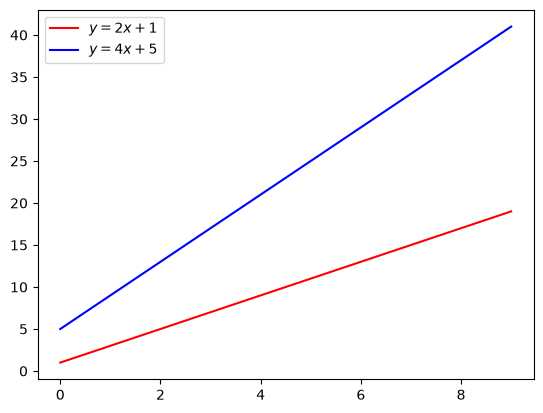

In [14]:
y_ = 4*x +5

sns.lineplot(x=x, y=y, color = 'red', label = '$y = 2x+1$')
sns.lineplot(x=x, y=y_, color = 'blue', label = '$y = 4x +5$')

From that we can see that the rate of change $m$ determines the slope - bigger the $m$ value, the steeper the slope of the lineplot. Real data rarely forms a perfectly straight line, but if there is any linear property, data points tend to swarm around a certain line. The point of the linear regression is to find the proper placement of the line based on the data distribution. In this case 'proper placement' means finding the smallest residual between the line and the data points. The line here is a predicted value of $y$ based on $x$, and the residual is a difference between the data points and the prediction. In linear regression we want to find the smallest sum of squared difference, also known as sum of squared error (SSE), meaning best fit of the prediction line, and this in turn means the best prediction. In the case of regression we use slightly different notation than before:

$$y_i = b_0 + b_1x_i + e_i$$

where $e_i$ is an error. But because we don't work on the values that are known to us, we use the estimated values:

$$\hat{y} = \hat{b_0} + \hat{b_1}x_i$$

where $\hat{y}$ is a predicted value, and $\hat{b_0}$, $\hat{b_1}$ are estimated coefficients. We can find estimated error by:

$$\hat{e_i} = y_i - \hat{y_i}$$

which is just a difference between the actual value and predicted value.

So, to find the sum of squared error (SSE), we use: 
$$SSE = \sum_{i=1}^{n} (y_i - \hat{y_i})^2 = \sum_{i=1}^{n} (y_i - \hat{b_0} - \hat{b_1}x_i)^2$$

To solve that first we have to find $\hat{b_0}$ and $\hat{b_1}$ and for that the following formula is used:

$$\hat{b_1} = \frac{\sum_{i=1}^{n} (x_i - \bar{x})(y_i - \bar{y})}{\sum_{i=1}^{n} (x_i - \bar{x})^2},$$
$$\hat{b_0} = \bar{y} - \hat{b_1}\bar{x}$$

where $\bar{x}$ is mean of x and $\bar{y}$ is a mean of y.

Next we can perform linear regression using scikit-learn library:

In [15]:
from sklearn.linear_model import LinearRegression

X = data[['height']]
y = data['weight']

model = LinearRegression()
model.fit(X.values, y)

model.intercept_, model.coef_

(-37.45572947842834, array([0.55064625]))

/usr/lib/python3/dist-packages/sklearn/base.py:486: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


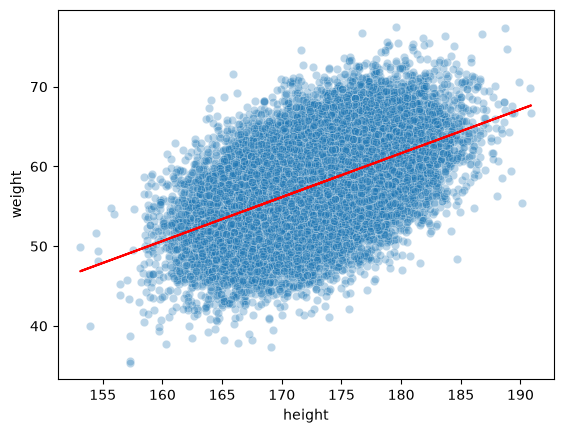

In [16]:
sns.scatterplot(data = data, x= 'height', y='weight', alpha = 0.3)
plt.plot(data['height'], model.predict(data[['height']]), color='red')


In [17]:
prediction = model.predict([[179]])
prediction

array([61.10994971])

Above we have coefficient (0.5), intercept (-37.4) and prediction of 61.1 kg for a person who is 179 cm tall. The weight seems very low for someone of that height, but at this point, it is simply a reflection of the data we are working with. Now we can split the data set on training (80%) and test (20%) subsets and actually test how well will the test actually perform.

#### 4. Coefficient of determination

Coefficient of determination or $R^2$ is a statistical measure of how well the model, based on independent variable x, explains the dependent variable y. The value of $R^2$ ranges between 1 and 0. 1 means perfect explanation and predicted values are the same as actual values, and closer the values get to 0, the worse the precision of predictions.

$R^2$ measures the amount of variability that is explained by the model, or how close to our prediction the value of y is.

To calculate the $R^2$, we have to:

1. Get the mean value of y, $\bar{y}$
2. Calculate the sum of squared differences of all observations of y and the mean of y (SStot), where $SStot = {\sum_{i=1}^{n}({y_i - \bar{y}})^2}$.
3. Calculate the sum of squared errors: $SSE = \sum_{i=1}^{n} (y_i - \hat{b_0} - \hat{b_1}x_i)^2$
4. Calculate $R^2 = 1 - \frac{SSE}{SStot}$

SSE is derived from the model itself, since the estimated values ($\hat{b_0}, \hat{b_1}$) are estimated by the model. SStot is calculated from the summation of squares of perpendicular distance of the data points and the mean line. SSE on the other hand is calculated from the summation of squares of perpendicular distance of the data points and the prediction line estimated by the model. The smaller the SSE, the $\frac{SSE}{SStot}$ is a smaller fraction, the bigger the $R^2$ becomes. When SSE derived from the model is smaller than SStot, this means better-fitted model.

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

X = data[['height']]
y = data['weight']

model = LinearRegression()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model.fit(X_train, y_train)

model.intercept_, model.coef_

(-37.075219531149884, array([0.54846197]))

Evaluation based on test set:

In [19]:
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

np.sqrt(mse), r2

(4.592002194326025, 0.26059113512888565)

Here I take the root of mean square error because otherwise the result is in $kg^2$, which is very unintuitive and difficult to interpret. After that, we can expect 4.59kg error from our model. Now we can compare $R^2$ values of training and test sets.

In [20]:
y_train_pred = model.predict(X_train)

r22 = r2_score(y_train, y_train_pred)
r22

0.2508830163228677

What happens here is that the model trains on X_train and y_train subsets by getting familiar with the relationship between x_train and y_train and makes estimates based on those values. Better fitted regression means higher $R^2$, and more data points are accounted for by the model. Then we test those estimations on the test subset (which is data points that the model has never seen before), by making estimations of an unknown y_test based on x_test. From that we get the second $R^2$ value. By comparing the training $R^2$ value to the second one, we can tell how consistently the predictions are performed on both data subsets. In my case both $R^2$ values are very close (0.25 and 0.26), meaning that the models predictions are consistent, but because those values are rather low ($R^2$ value ranges from 0 to 1, where 1 is complete explanation), those predictions do not account for majority of the relationship in the dataset. So, given the data we have and the model trained on that data, we cannot accurately predict a person's weight based on their height – meaning that there are more factors at play that were not included in the model.

For better result we can quickly try another dataset, that also has linear relationship and is slightly less complicated than the human phenomenon - seaborn mpg dataset containing various properties of cars.

In [21]:
mpg = sns.load_dataset('mpg')
mpg['weight'] = mpg['weight']*0.4535924 #converting to kg
mpg.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,1589.387770,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,1675.116733,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,1558.543486,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,1557.182709,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,1564.440188,10.5,70,usa,ford torino


In [22]:
mpg_corr = mpg[['weight', 'mpg', 'displacement', 'horsepower', 'acceleration']].corr()
mpg_corr

,weight,mpg,displacement,horsepower,acceleration
weight,1.000000,-0.831741,0.932824,0.864538,-0.417457
mpg,-0.831741,1.000000,-0.804203,-0.778427,0.420289
displacement,0.932824,-0.804203,1.000000,0.897257,-0.543684
horsepower,0.864538,-0.778427,0.897257,1.000000,-0.689196
acceleration,-0.417457,0.420289,-0.543684,-0.689196,1.000000


<Axes: >

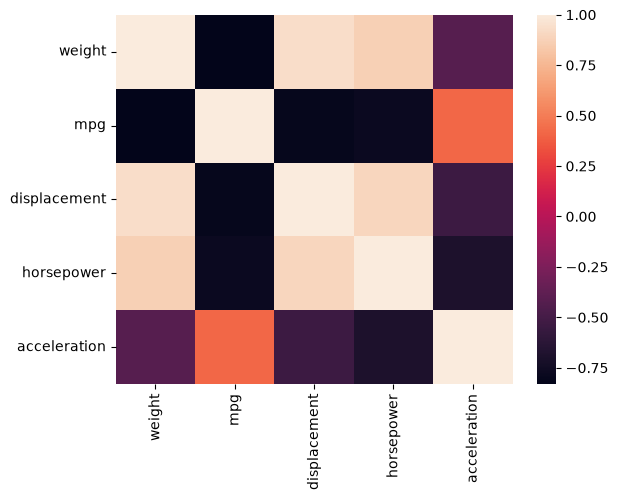

In [23]:
sns.heatmap(mpg_corr)

<Axes: xlabel='displacement', ylabel='weight'>

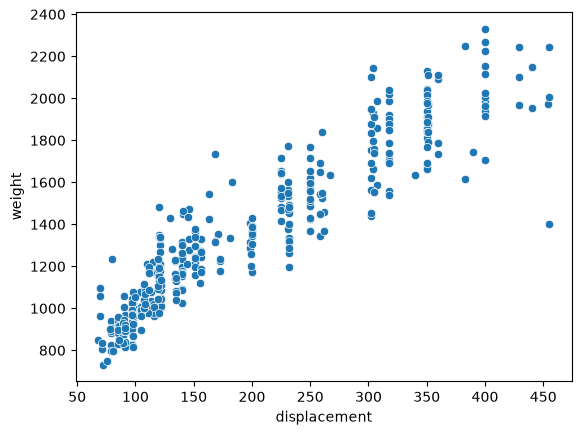

In [24]:
sns.scatterplot(data = mpg, x= 'displacement', y= 'weight')

In [25]:
model = LinearRegression()
X = mpg[['displacement']]
y = mpg['weight']

model.fit(X, y)

model.coef_, model.intercept_

(array([3.43644283]), 682.6650581627945)

In [26]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
np.sqrt(mse), r2


(129.56516432750917, 0.892461517908172)

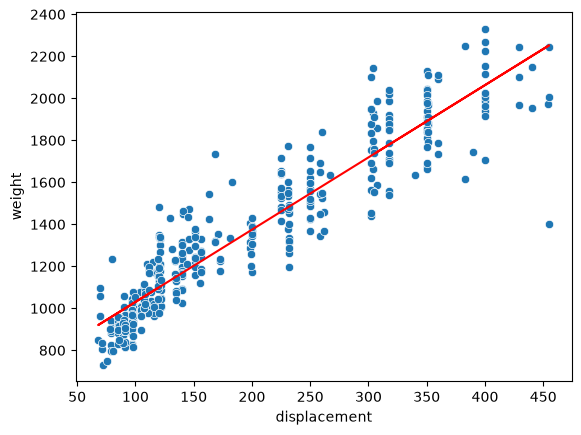

In [27]:
sns.scatterplot(data = mpg, x= 'displacement', y= 'weight')
plt.plot(mpg['displacement'], model.predict( mpg[['displacement']]), color='red')

In [28]:
y_trainpred = model.predict(X_train)

mse = mean_squared_error(y_train, y_trainpred)
r2 = r2_score(y_train, y_trainpred)

np.sqrt(mse), r2

(140.42977831100333, 0.8639314838218474)

Here we see much higher $R^2$ value, while still being consistent: 0.89 and 0.86, which means that this model is not only reliable but also accounts for more variance in the data. We can also notice that the root of mean squared error is much higher (129kg and 140kg), but this is due to completely different number ranges in the dataset, as cars are generally much heavier than humans.

#### 5. Non-linear transformation

Often it turns out that the relationship in the data set is not linear, so the linear regression is not doing well with the prediction. But in this case there is still hope in applying a nonlinear transformation to the predictor or outcome. There is a real world example in the relationship between national GDP per capita and the life expectancy.

In [ ]:
data2 = pd.read_csv('gdp_life.csv')
data2.head()

,Unnamed: 0,Country Name,Country Code,year,gdp_per_capita,life_expectancy,log_gdp
0,0,Aruba,ABW,2002,21307.248251,73.135000,9.966803
1,1,Africa Eastern and Southern,AFE,2002,630.512328,53.206744,6.446533
2,2,Afghanistan,AFG,2002,178.954088,56.225000,5.187129
3,3,Africa Western and Central,AFW,2002,619.337335,51.108247,6.428650
4,4,Angola,AGO,2002,999.065856,47.874000,6.906821


<Axes: xlabel='gdp_per_capita', ylabel='life_expectancy'>

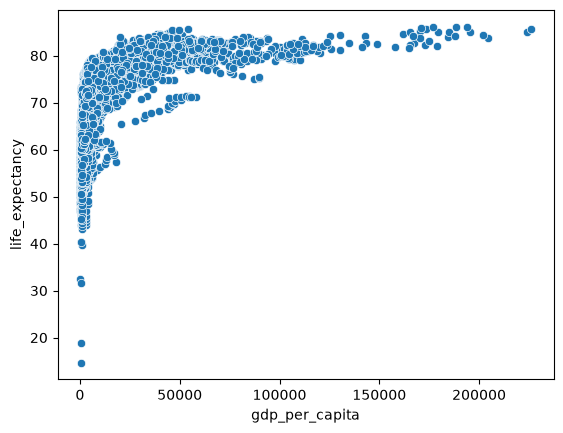

In [30]:
sns.scatterplot(data = data2, x = 'gdp_per_capita', y= 'life_expectancy')

This phenomenon is called the Preston curve and shows that benefits diminish after a certain level of GDP per capita is reached. We can also see that - as the name suggests - the relationship is not linear, so the linear regression will not work well:

In [31]:
X = data2[['gdp_per_capita']]
y = data2['life_expectancy']

model = LinearRegression()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


model.fit(X_train, y_train)

y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
np.sqrt(mse), r2

(6.999106161241229, 0.32952624971986577)

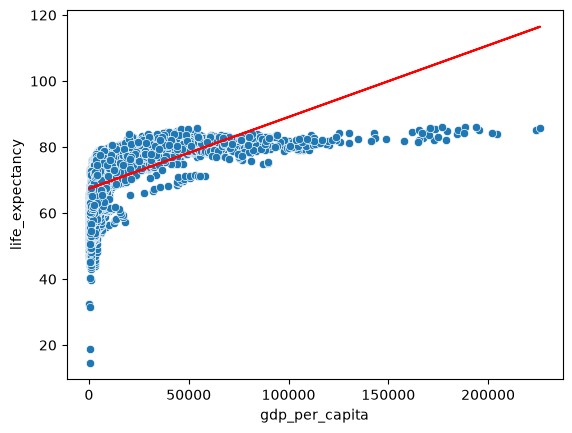

In [32]:
sns.scatterplot(data = data2, x = 'gdp_per_capita', y = 'life_expectancy')
plt.plot(data2['gdp_per_capita'], model.predict(data2[['gdp_per_capita']]), color='red')

Since the curve has a somewhat logarithmic shape, we can try applying a logarithmic transformation to the x values ​​and see how much this improves the result.

In [33]:
data2['log'] = np.log(data2['gdp_per_capita'])

X = data2[['log']]
y = data2['life_expectancy']

model = LinearRegression()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
np.sqrt(mse), r2

(4.789069293723532, 0.6860945473370934)

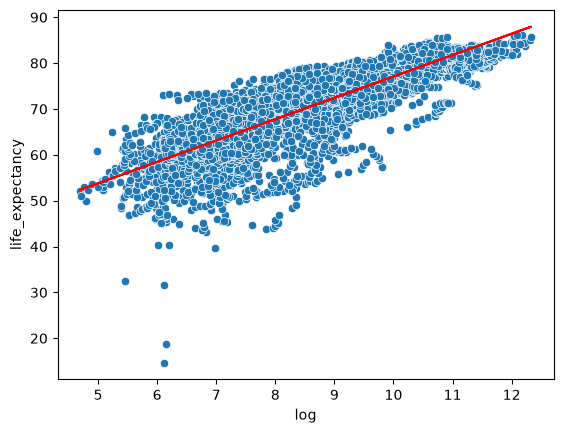

In [34]:
sns.scatterplot(data = data2, x = 'log', y = 'life_expectancy')
plt.plot(data2['log'], model.predict(data2[['log']]), color='red')

Now our prediction line is much better fitted and the $R^2$ has value more than doubled from 0.32 to 0.68. We can now try to predict the life expectancy of any given country. As an example I will take my own country, Poland. According to World Bank Group (https://data.worldbank.org/indicator/NY.GDP.PCAP.CD?locations=PL ), Poland's GDP per capita in 2024 was 25,103$ and according to the same source (https://data.worldbank.org/indicator/SP.DYN.LE00.IN?locations=PL ) Poland's life expectancy at birth was 78 years in 2024.

In [35]:
model.predict([[np.log(25103)]])

/usr/lib/python3/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([77.69512776])

Prediction generated by our model is almost exactly the same as the data from World Bank Group (predicted: 77.6, actual data: 78), which is promising, although there is still some variance that our model does not cover.